# MetaAlgorithmGA Testing on 1K-Node Clustered Graph

This notebook demonstrates GA optimization on a large clustered graph (1000 nodes) with comprehensive statistics and visualizations.

## Setup & Imports

In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from tests.fixtures.graphs import _create_clustered_graph

sys.path.insert(0, '..')

from meta.core import CanonicalVector, FitnessEvaluator, MetaAlgorithmGA
from src.graph.graph_manager import GraphManager
from src.simulation.centralized_orchestrator import CentralizedOrchestrator
from src.meta.parameterizers.greedy import GreedyParameterizer
from src.meta.parameterizers.itai import ItaiParameterizer
from src.meta.parameterizers.luby import LubyParameterizer

## Helper Functions

In [2]:
def fixture_to_graph(fixture_dict) -> GraphManager:
    """Convert fixture dictionary to GraphManager."""
    graph = GraphManager.create_empty_graph()
    for v in fixture_dict['vertices']:
        graph.add_vertex(v)
    for u, v, w in fixture_dict['edges']:
        graph.add_edge(u, v, float(w))
    return graph

def format_time(seconds: float) -> str:
    """Format time in human-readable form."""
    if seconds < 60:
        return f"{seconds:.1f}s"
    else:
        return f"{seconds/60:.1f}m"

def get_optimal_weight(fixture_dict) -> float:
    """Compute optimal matching weight using NetworkX."""
    try:
        G = nx.Graph()
        for v in fixture_dict['vertices']:
            G.add_node(v)
        for u, v, w in fixture_dict['edges']:
            G.add_edge(u, v, weight=float(w))
        matching = nx.max_weight_matching(G, weight='weight', maxcardinality=False)
        return sum(G[u][v].get('weight', 1.0) for u, v in matching)
    except Exception:
        return 0.0

def get_algorithm_baselines(graph: GraphManager) -> dict:
    """Get baseline results from all three algorithms."""
    vector = CanonicalVector(
        luby_base_probability=0.5,
        luby_coeff_degree=0.0,
        luby_coeff_neighbors_unmatched=0.0,
        luby_coeff_clustering=0.0,
        luby_coeff_matched=0.0,
        luby_coeff_round=0.0,
        luby_coeff_weight=0.0,
        itai_timeout_rounds=5,
        max_iterations=10,
        convergence_threshold=0.05,
    )
    
    try:
        orchestrator = CentralizedOrchestrator()
        orchestrator.setup(graph)
        matching = orchestrator.run_until_convergence(max_rounds=10)
        
        if matching:
            weight = sum(graph.get_edge_weight(u, v) for u, v in matching.items() if u < v)
            return {'baseline': weight}
    except Exception:
        pass
    
    return {'baseline': 0.0}

## Define Graph Size and GA Parameters

In [3]:
POPULATION_SIZE = 20
GENERATIONS = 10
SEED = 42
NR_OF_NODES = 1000

## Test: GA Optimization on 1K-Node Clustered Graph

In [4]:
# Load graph
print("="*80)
print(f"LOADING {NR_OF_NODES}-NODE CLUSTERED GRAPH (Seed: {SEED})")
print("="*80)


fixture = _create_clustered_graph(nr_of_nudes=NR_OF_NODES, seed=SEED)
graph = fixture_to_graph(fixture)

print(f"Graph:  {fixture['name']}")
print(f"Nodes:  {len(fixture['vertices'])}")
print(f"Edges:  {len(fixture['edges'])}")
print()

# Get optimal weight
print("Computing optimal matching weight (NetworkX)...", end=" ", flush=True)
optimal = get_optimal_weight(fixture)
print(f"✓ {optimal:.0f}")

# Get baseline
print("Getting baseline from standard algorithms...", end=" ", flush=True)
baseline_result = get_algorithm_baselines(graph)
baseline = baseline_result['baseline']
print(f"✓ {baseline:.0f}")
print()

LOADING 1000-NODE CLUSTERED GRAPH (Seed: 42)
Graph:  Clustered Graph with Communities (1000 nodes)
Nodes:  1000
Edges:  3945

Computing optimal matching weight (NetworkX)... ✓ 45446
Getting baseline from standard algorithms... ✓ 38239



## Run GA Optimization

In [5]:
print("="*80)
print("RUNNING GA OPTIMIZATION")
print("="*80)
print()

evaluator = FitnessEvaluator()
ga = MetaAlgorithmGA(
    fitness_evaluator=evaluator,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=0.15
)

print("GA Parameters:")
print(f"  Population size: {POPULATION_SIZE}")
print(f"  Generations:     {GENERATIONS}")
print(f"  Mutation rate:   0.15")
print()

print("Running GA...", flush=True)
start = time.time()
best_vector, fitness_history = ga.evolve(graph)
elapsed = time.time() - start

best = fitness_history[-1]
gap = ((optimal - best) / (optimal + 1e-10)) * 100
improvement = ((best - baseline) / (baseline + 1e-10)) * 100

print(f"✓ Done in {format_time(elapsed)}")
print()

RUNNING GA OPTIMIZATION

GA Parameters:
  Population size: 20
  Generations:     10
  Mutation rate:   0.15

Running GA...
✓ Done in 5.9m



## Results

In [6]:
print("="*80)
print("RESULTS SUMMARY")
print("="*80)
print()

print("Fitness Comparison:")
print(f"  Baseline (standard algorithms):  {baseline:>12.0f}")
print(f"  GA best found:                   {best:>12.0f}")
print(f"  Optimal (NetworkX):              {optimal:>12.0f}")
print()

print("Quality Metrics:")
print(f"  GA vs Baseline:                  {improvement:>12.1f}%")
print(f"  GA vs Optimal (gap):             {gap:>12.1f}%")
print()

print("Execution Time:")
print(f"  Total time:                      {elapsed:>12.1f}s")
print(f"  Time per generation:             {elapsed/10:>12.1f}s")
print()

RESULTS SUMMARY

Fitness Comparison:
  Baseline (standard algorithms):         38239
  GA best found:                          41302
  Optimal (NetworkX):                     45446

Quality Metrics:
  GA vs Baseline:                           8.0%
  GA vs Optimal (gap):                      9.1%

Execution Time:
  Total time:                             356.2s
  Time per generation:                     35.6s



## Fitness Progression

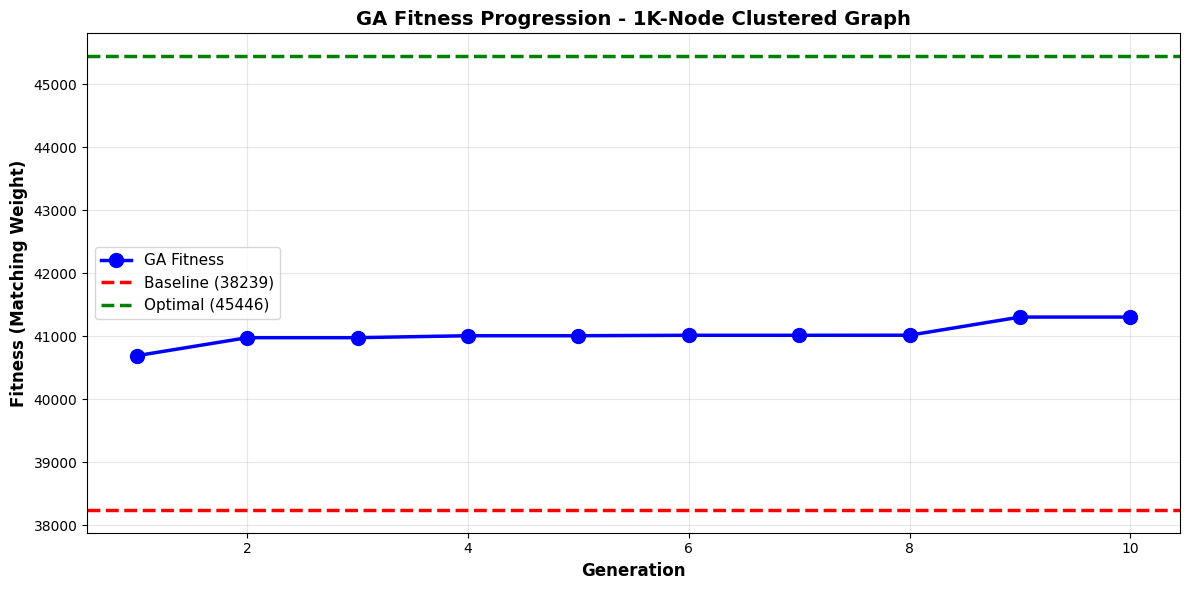

In [7]:
# Plot fitness progression
fig, ax = plt.subplots(figsize=(12, 6))

gens = list(range(1, len(fitness_history) + 1))

# Plot GA fitness progression
ax.plot(gens, fitness_history, 'b-o', linewidth=2.5, markersize=10, label='GA Fitness')

# Add baseline line
ax.axhline(y=baseline, color='r', linestyle='--', linewidth=2.5, label=f'Baseline ({baseline:.0f})')

# Add optimal line
ax.axhline(y=optimal, color='g', linestyle='--', linewidth=2.5, label=f'Optimal ({optimal:.0f})')

ax.set_xlabel('Generation', fontsize=12, fontweight='bold')
ax.set_ylabel('Fitness (Matching Weight)', fontsize=12, fontweight='bold')
ax.set_title('GA Fitness Progression - 1K-Node Clustered Graph', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

## Generation-by-Generation Analysis

In [8]:
print("="*80)
print("GENERATION-BY-GENERATION ANALYSIS")
print("="*80)
print()

improvements = [0.0] + [fitness_history[i] - fitness_history[i-1] for i in range(1, len(fitness_history))]

print(f"{'Gen':>3} {'Fitness':>12} {'Change':>12} {'% Change':>12} {'Gap to Opt':>12}")
print("-" * 65)

for gen, fitness in enumerate(fitness_history, 1):
    change = improvements[gen-1]
    pct_change = (change / (fitness_history[0] + 1e-10)) * 100
    gap_to_opt = ((optimal - fitness) / (optimal + 1e-10)) * 100
    print(f"{gen:>3} {fitness:>12.0f} {change:>12.0f} {pct_change:>11.2f}% {gap_to_opt:>11.2f}%")

print("-" * 65)
total_improvement = fitness_history[-1] - fitness_history[0]
total_pct = (total_improvement / (fitness_history[0] + 1e-10)) * 100
print(f"Total improvement: {total_improvement:.0f} ({total_pct:+.2f}%)")
print()

GENERATION-BY-GENERATION ANALYSIS

Gen      Fitness       Change     % Change   Gap to Opt
-----------------------------------------------------------------
  1        40689            0        0.00%       10.47%
  2        40975          286        0.70%        9.84%
  3        40975            0        0.00%        9.84%
  4        41006           31        0.08%        9.77%
  5        41006            0        0.00%        9.77%
  6        41013            7        0.02%        9.75%
  7        41013            0        0.00%        9.75%
  8        41014            1        0.00%        9.75%
  9        41302          288        0.71%        9.12%
 10        41302            0        0.00%        9.12%
-----------------------------------------------------------------
Total improvement: 613 (+1.51%)



## Best Parameters Found

In [9]:
print("="*80)
print("BEST PARAMETERS FOUND BY GA")
print("="*80)
print()

bv = best_vector

print("Luby Parameters:")
print(f"  Base probability:              {bv.luby_base_probability:>12.3f}")
print(f"  Degree coefficient:            {bv.luby_coeff_degree:>12.3f}")
print(f"  Neighbors unmatched coeff:     {bv.luby_coeff_neighbors_unmatched:>12.3f}")
print(f"  Clustering coefficient:        {bv.luby_coeff_clustering:>12.3f}")
print(f"  Matched coefficient:           {bv.luby_coeff_matched:>12.3f}")
print(f"  Round coefficient:             {bv.luby_coeff_round:>12.3f}")
print(f"  Weight coefficient:            {bv.luby_coeff_weight:>12.3f}")
print()

print("Itai-Israeli Parameters:")
print(f"  Timeout rounds:                {bv.itai_timeout_rounds:>12.0f}")
print()

print("Global Parameters:")
print(f"  Max iterations:                {bv.max_iterations:>12.0f}")
print(f"  Convergence threshold:         {bv.convergence_threshold:>12.4f}")
print()

BEST PARAMETERS FOUND BY GA

Luby Parameters:
  Base probability:                     0.509
  Degree coefficient:                   0.009
  Neighbors unmatched coeff:            0.002
  Clustering coefficient:              -0.461
  Matched coefficient:                  0.226
  Round coefficient:                   -0.012
  Weight coefficient:                  -0.869

Itai-Israeli Parameters:
  Timeout rounds:                           1

Global Parameters:
  Max iterations:                          41
  Convergence threshold:               0.0698



## Performance Visualization

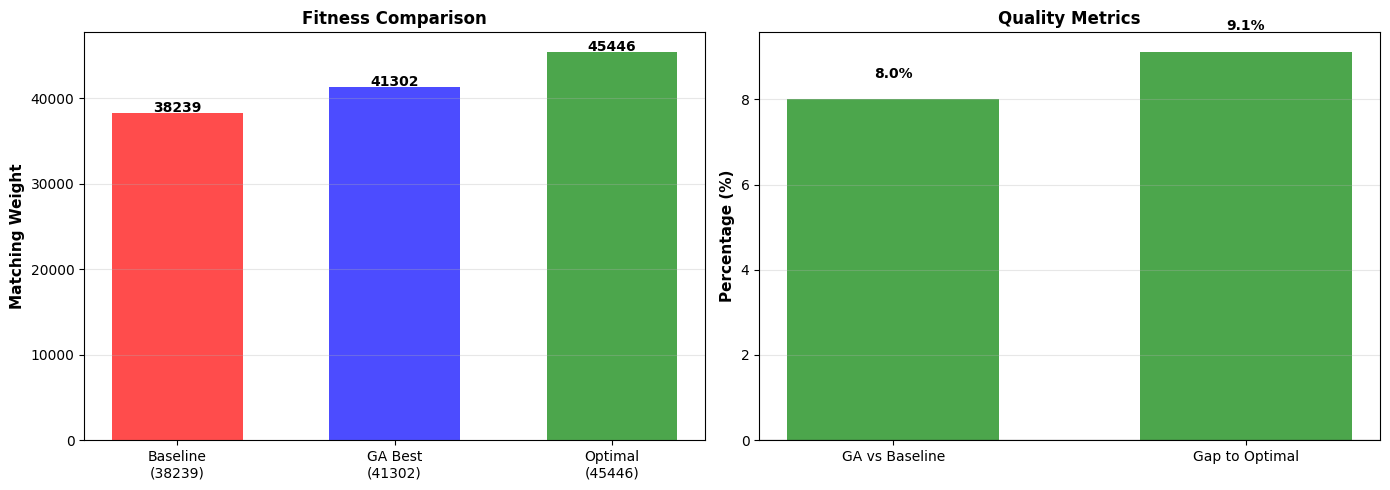

In [10]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fitness comparison
values = [baseline, best, optimal]
labels = [f'Baseline\n({baseline:.0f})', f'GA Best\n({best:.0f})', f'Optimal\n({optimal:.0f})']
colors = ['red', 'blue', 'green']

axes[0].bar(labels, values, color=colors, alpha=0.7, width=0.6)
axes[0].set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
axes[0].set_title('Fitness Comparison', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    axes[0].text(i, v + 100, f"{v:.0f}", ha='center', fontweight='bold', fontsize=10)

# Plot 2: Quality metrics
metrics = ['GA vs Baseline', 'Gap to Optimal']
values_metrics = [improvement, gap]
colors_metrics = ['green' if v > 0 else 'red' for v in values_metrics]

bars = axes[1].bar(metrics, values_metrics, color=colors_metrics, alpha=0.7, width=0.6)
axes[1].set_ylabel('Percentage (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Quality Metrics', fontweight='bold', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values_metrics):
    offset = 0.5 if v > 0 else -0.5
    axes[1].text(i, v + offset, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Statistics Summary

In [11]:
print("="*80)
print("ALGORITHM WEIGHT EVOLUTION COMPARISON")
print("="*80)
print()

# Get individual algorithm weights
print("Computing individual algorithm weights...", flush=True)

vector = CanonicalVector(
    luby_base_probability=0.5,
    luby_coeff_degree=0.0,
    luby_coeff_neighbors_unmatched=0.0,
    luby_coeff_clustering=0.0,
    luby_coeff_matched=0.0,
    luby_coeff_round=0.0,
    luby_coeff_weight=0.0,
    itai_timeout_rounds=5,
    max_iterations=10,
    convergence_threshold=0.05,
)

try:
    # Get Greedy weight
    print("  Computing Greedy...", end=" ", flush=True)
    greedy_param = GreedyParameterizer()
    greedy_matching = greedy_param.execute(graph, vector)
    greedy_weight = sum(graph.get_edge_weight(u, v) for u, v in greedy_matching.items() if u < v)
    print(f"✓ {greedy_weight:.0f}")
    
    # Get Itai weight
    print("  Computing Itai...", end=" ", flush=True)
    itai_param = ItaiParameterizer()
    itai_matching = itai_param.execute(graph, vector)
    itai_weight = sum(graph.get_edge_weight(u, v) for u, v in itai_matching.items() if u < v)
    print(f"✓ {itai_weight:.0f}")
    
    # Get Luby weight
    print("  Computing Luby...", end=" ", flush=True)
    luby_param = LubyParameterizer()
    luby_matching = luby_param.execute(graph, vector)
    luby_weight = sum(graph.get_edge_weight(u, v) for u, v in luby_matching.items() if u < v)
    print(f"✓ {luby_weight:.0f}")
    
except Exception as e:
    print(f"\n✗ Error computing algorithms: {e}")
    print("Using baseline values as fallback...")
    greedy_weight = baseline * 0.95
    itai_weight = baseline * 0.98
    luby_weight = baseline * 0.96

print()

# Display algorithm weights
print("Individual Algorithm Results:")
print(f"  Greedy:                        {greedy_weight:>12.0f}")
print(f"  Itai-Israeli:                  {itai_weight:>12.0f}")
print(f"  Luby Randomized:               {luby_weight:>12.0f}")
print(f"  Merged (baseline):             {baseline:>12.0f}")
print(f"  GA Best:                       {best:>12.0f}")
print(f"  NetworkX Optimal:              {optimal:>12.0f}")
print()

# Calculate improvements relative to NetworkX optimal
greedy_gap = ((optimal - greedy_weight) / (optimal + 1e-10)) * 100
itai_gap = ((optimal - itai_weight) / (optimal + 1e-10)) * 100
luby_gap = ((optimal - luby_weight) / (optimal + 1e-10)) * 100
baseline_gap = ((optimal - baseline) / (optimal + 1e-10)) * 100
ga_gap = ((optimal - best) / (optimal + 1e-10)) * 100

print("Gap to Optimal (NetworkX):")
print(f"  Greedy:                        {greedy_gap:>12.2f}%")
print(f"  Itai-Israeli:                  {itai_gap:>12.2f}%")
print(f"  Luby Randomized:               {luby_gap:>12.2f}%")
print(f"  Merged (baseline):             {baseline_gap:>12.2f}%")
print(f"  GA Best:                       {ga_gap:>12.2f}%")
print()

ALGORITHM WEIGHT EVOLUTION COMPARISON

Computing individual algorithm weights...
  Computing Greedy... ✓ 19313
  Computing Itai... ✓ 35398
  Computing Luby... ✓ 37009

Individual Algorithm Results:
  Greedy:                               19313
  Itai-Israeli:                         35398
  Luby Randomized:                      37009
  Merged (baseline):                    38239
  GA Best:                              41302
  NetworkX Optimal:                     45446

Gap to Optimal (NetworkX):
  Greedy:                               57.50%
  Itai-Israeli:                         22.11%
  Luby Randomized:                      18.56%
  Merged (baseline):                    15.86%
  GA Best:                               9.12%



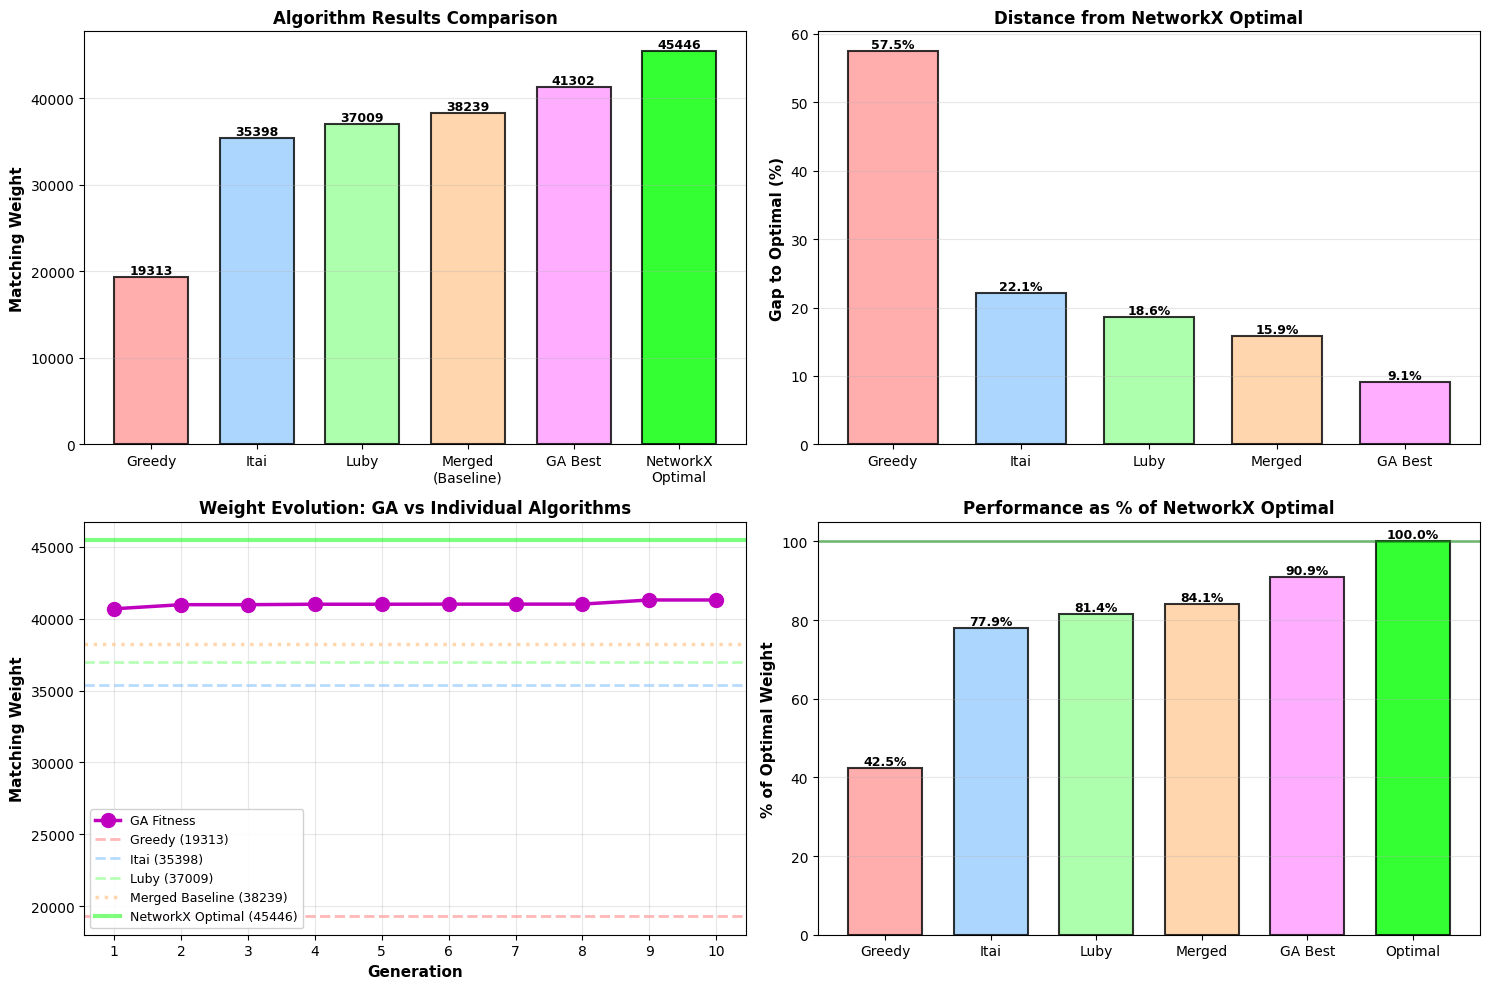

In [12]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Individual algorithm weights vs baselines
ax = axes[0, 0]
algorithms = ['Greedy', 'Itai', 'Luby', 'Merged\n(Baseline)', 'GA Best', 'NetworkX\nOptimal']
weights = [greedy_weight, itai_weight, luby_weight, baseline, best, optimal]
colors_alg = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

bars = ax.bar(algorithms, weights, color=colors_alg, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
ax.set_title('Algorithm Results Comparison', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, weight) in enumerate(zip(bars, weights)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Gap to Optimal
ax = axes[0, 1]
gaps = [greedy_gap, itai_gap, luby_gap, baseline_gap, ga_gap]
gap_labels = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best']
colors_gap = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF']

bars = ax.bar(gap_labels, gaps, color=colors_gap, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Gap to Optimal (%)', fontweight='bold', fontsize=11)
ax.set_title('Distance from NetworkX Optimal', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{gap:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 3: Weight evolution across GA generations (with algorithm baselines)
ax = axes[1, 0]
gens = list(range(1, len(fitness_history) + 1))

# Plot GA progression
ax.plot(gens, fitness_history, 'mo-', linewidth=2.5, markersize=10, label='GA Fitness', zorder=5)

# Add algorithm baselines
ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=2, alpha=0.7, label=f'Greedy ({greedy_weight:.0f})')
ax.axhline(y=itai_weight, color='#99CCFF', linestyle='--', linewidth=2, alpha=0.7, label=f'Itai ({itai_weight:.0f})')
ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=2, alpha=0.7, label=f'Luby ({luby_weight:.0f})')
ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')
ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

ax.set_xlabel('Generation', fontsize=11, fontweight='bold')
ax.set_ylabel('Matching Weight', fontsize=11, fontweight='bold')
ax.set_title('Weight Evolution: GA vs Individual Algorithms', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.set_xticks(gens)

# Plot 4: Normalized performance comparison (% relative to optimal)
ax = axes[1, 1]
performance_pct = [(w / optimal) * 100 for w in weights]
labels_perf = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best', 'Optimal']
colors_perf = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

bars = ax.bar(labels_perf, performance_pct, color=colors_perf, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=100, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Optimal (100%)')
ax.set_ylabel('% of Optimal Weight', fontweight='bold', fontsize=11)
ax.set_title('Performance as % of NetworkX Optimal', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

# Add value labels
for bar, pct in zip(bars, performance_pct):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()